# Notebook 14: Mehrotra Predictor-Corrector and Gondzio Corrections

In notebooks 7–10 we built an interior-point method with a fixed centering
parameter $\sigma \in (0, 1)$.  A small $\sigma$ gives fast convergence far from
the optimal but becomes numerically fragile; a large $\sigma$ is safe but slow.

**Mehrotra's predictor-corrector** (1992) solves this by computing $\sigma$
adaptively in each iteration — at essentially no extra cost, since it reuses the
same LDL$^T$ factorization.

**Gondzio's multiple centrality corrections** (1996) go further: after the
predictor-corrector step, they identify complementarity pairs that are far from
the central path and add targeted corrections to bring them in line.

**Learning objectives**
- Understand why fixed $\sigma$ is suboptimal
- Derive Mehrotra's affine step and the $\sigma = (\mu_{\text{aff}}/\mu)^3$ formula
- Implement the corrector step using the existing LDL$^T$ factorization
- Add Gondzio multiple centrality corrections
- Compare iterations: basic IPM vs Mehrotra PC vs Mehrotra + Gondzio

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import ldl, solve_triangular

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

## 1. The Basic IPM with Fixed Centering

Recall from notebook 7: the perturbed KKT system for
$\min_{x_l \le x \le x_u} f(x)$ has complementarity
$$Z_l S_l e = \sigma \mu e, \qquad Z_u S_u e = \sigma \mu e$$

where $S_l = \text{diag}(x - x_l)$, $S_u = \text{diag}(x_u - x)$.

After eliminating $dz_l, dz_u$ from the KKT system, the condensed system for
$(dx, dy)$ is:
$$\begin{pmatrix} H + \Sigma & J^T \\ J & 0 \end{pmatrix}
  \begin{pmatrix} dx \\ dy \end{pmatrix}
= \begin{pmatrix} r_d \\ r_p \end{pmatrix}$$

where $\Sigma = Z_l S_l^{-1} + Z_u S_u^{-1}$ and the RHS encodes both the
gradient residual and the centering term $\sigma\mu$.

The right-hand-side for $dx$ with centering $\sigma\mu$ is:
$$r_d = -(\nabla f + J^T y - z_l + z_u) + \frac{\sigma\mu}{s_l} - \frac{\sigma\mu}{s_u}$$

In [2]:
class KKTSystem:
    """
    Condensed KKT system for the barrier IPM.
    Caches the LDL^T factorization so it can be reused with multiple RHS vectors.

    Variables: min f(x)  s.t. g(x)=0,  x_l <= x <= x_u
    Lagrangian: L = f + y^T g  (ripopt sign convention)
    """

    def __init__(self, H, Sigma, J):
        """
        H     : (n,n) Hessian of Lagrangian (positive semi-definite)
        Sigma : (n,)  diagonal of Z_l/S_l + Z_u/S_u
        J     : (m,n) constraint Jacobian
        """
        n, m = H.shape[0], J.shape[0]
        self.n = n
        self.m = m
        K = np.block([
            [H + np.diag(Sigma),  J.T],
            [J,                   np.zeros((m, m))]
        ])
        # Add regularisation for numerical stability
        K += 1e-10 * np.eye(n + m)
        self.K = K
        # Factorize once
        self.K_inv = np.linalg.inv(K)  # simple inversion for illustration

    def solve(self, rhs):
        """Solve K * [dx; dy] = rhs, return (dx, dy)."""
        sol = self.K_inv @ rhs
        return sol[:self.n], sol[self.n:]


def build_rhs(grad_f, g, J, y, z_l, z_u, s_l, s_u, x_l, x_u, sigma, mu):
    """
    Build the KKT right-hand side for a given centering sigma*mu.

    r_d = -(grad_f + J^T y - z_l + z_u)
          + sigma*mu/s_l (lower bound centering)
          - sigma*mu/s_u (upper bound centering)
    r_p = -g

    Returns concatenated [r_d; r_p]
    """
    # Dual residual
    r_d = -(grad_f + J.T @ y - z_l + z_u)

    # Add centering
    lower = np.isfinite(x_l)
    upper = np.isfinite(x_u)
    r_d[lower] += sigma * mu / np.maximum(s_l[lower], 1e-15)
    r_d[upper] -= sigma * mu / np.maximum(s_u[upper], 1e-15)

    r_p = -g
    return np.concatenate([r_d, r_p])


def build_rhs_with_cross_terms(grad_f, g, J, y, z_l, z_u, s_l, s_u, x_l, x_u,
                                sigma, mu, dz_l_aff, dz_u_aff, ds_l_aff, ds_u_aff):
    """
    Mehrotra corrector RHS: adds cross terms dz_aff * ds_aff from the affine step.

    r_d += (-dz_l_aff * ds_l_aff + sigma*mu) / s_l
           (the cross terms correct for nonlinearity in z*s = sigma*mu)
    """
    r_d = -(grad_f + J.T @ y - z_l + z_u)

    lower = np.isfinite(x_l)
    upper = np.isfinite(x_u)

    sl = np.maximum(s_l, 1e-15)
    su = np.maximum(s_u, 1e-15)

    # Lower bound correction
    r_d[lower] += (sigma*mu - dz_l_aff[lower]*ds_l_aff[lower]) / sl[lower]

    # Upper bound correction
    r_d[upper] -= (sigma*mu - dz_u_aff[upper]*ds_u_aff[upper]) / su[upper]

    r_p = -g
    return np.concatenate([r_d, r_p])


print("KKT system utilities defined.")

KKT system utilities defined.


## 2. The Affine (Predictor) Step

Set $\sigma = 0$ (no centering) in the KKT system.  This gives the **affine scaling**
direction — the Newton step that ignores the barrier:
$$r_d^{\text{aff}} = -(\nabla f + J^T y - z_l + z_u)$$
$$r_p^{\text{aff}} = -g$$

The affine step tells us: *if we had no barrier, how far could we step?*

We compute the **maximum step** in the affine direction before hitting a bound:
$$\alpha_{\text{aff}}^{\max} = \min\left(1,\; \min_{i: ds_{l,i} < 0} \frac{-s_{l,i}}{ds_{l,i}},\;
  \min_{i: ds_{u,i} < 0} \frac{-s_{u,i}}{ds_{u,i}}\right)$$

Then the **affine complementarity** is:
$$\mu_{\text{aff}} = \frac{(z_l + \alpha_{\text{aff}} dz_l)^T (s_l + \alpha_{\text{aff}} ds_l) +
                         (z_u + \alpha_{\text{aff}} dz_u)^T (s_u + \alpha_{\text{aff}} ds_u)}
                        {n_b}$$
where $n_b$ is the number of bound constraints.

In [3]:
def fraction_to_boundary(s, ds, tau=0.995):
    """
    Maximum step size alpha such that s + alpha*ds >= (1-tau)*s  (i.e., stays positive).
    Returns alpha in (0, 1].
    """
    neg = ds < 0
    if not np.any(neg):
        return 1.0
    alphas = -tau * s[neg] / ds[neg]
    return min(1.0, np.min(alphas))


def affine_step(kkt_sys, grad_f, g, J, y, z_l, z_u, s_l, s_u, x_l, x_u):
    """
    Compute the affine (sigma=0, no centering) predictor step.

    Returns (dx_aff, dy_aff, dz_l_aff, dz_u_aff, ds_l_aff, ds_u_aff,
             alpha_aff, mu_aff)
    """
    rhs_aff = build_rhs(grad_f, g, J, y, z_l, z_u, s_l, s_u, x_l, x_u,
                         sigma=0.0, mu=0.0)
    dx_aff, dy_aff = kkt_sys.solve(rhs_aff)

    # Bound-multiplier updates
    lower = np.isfinite(x_l)
    upper = np.isfinite(x_u)
    dz_l_aff = np.zeros_like(z_l)
    dz_u_aff = np.zeros_like(z_u)
    ds_l_aff = np.zeros_like(s_l)
    ds_u_aff = np.zeros_like(s_u)

    # ds_l = dx (lower slack decreases when x decreases)
    # ds_u = -dx (upper slack decreases when x increases)
    ds_l_aff[lower] =  dx_aff[lower]
    ds_u_aff[upper] = -dx_aff[upper]

    # dz_l from complementarity: (z_l + dz_l)(s_l + ds_l) = 0  (no centering)
    # => dz_l = (-z_l*ds_l - z_l*s_l) / s_l = -z_l/s_l * ds_l - z_l
    # More precisely: dz_l = (0 - z_l*ds_l) / s_l
    dz_l_aff[lower] = (-z_l[lower]*ds_l_aff[lower]) / np.maximum(s_l[lower], 1e-15)
    dz_u_aff[upper] = (-z_u[upper]*ds_u_aff[upper]) / np.maximum(s_u[upper], 1e-15)

    # Max step for slacks
    alpha_aff = 1.0
    if np.any(lower):
        alpha_aff = min(alpha_aff, fraction_to_boundary(s_l[lower], ds_l_aff[lower]))
    if np.any(upper):
        alpha_aff = min(alpha_aff, fraction_to_boundary(s_u[upper], ds_u_aff[upper]))
    if np.any(lower):
        alpha_aff = min(alpha_aff, fraction_to_boundary(z_l[lower], dz_l_aff[lower]))
    if np.any(upper):
        alpha_aff = min(alpha_aff, fraction_to_boundary(z_u[upper], dz_u_aff[upper]))

    # Affine complementarity
    z_l_aff = z_l + alpha_aff * dz_l_aff
    z_u_aff = z_u + alpha_aff * dz_u_aff
    s_l_aff = s_l + alpha_aff * ds_l_aff
    s_u_aff = s_u + alpha_aff * ds_u_aff

    n_b = np.sum(lower) + np.sum(upper)
    compl_aff = 0.0
    if np.any(lower):
        compl_aff += np.sum(z_l_aff[lower] * s_l_aff[lower])
    if np.any(upper):
        compl_aff += np.sum(z_u_aff[upper] * s_u_aff[upper])
    mu_aff = compl_aff / max(n_b, 1)

    return (dx_aff, dy_aff, dz_l_aff, dz_u_aff, ds_l_aff, ds_u_aff,
            alpha_aff, mu_aff)


print("Affine step function defined.")

Affine step function defined.


## 3. Mehrotra Centering Parameter

With the affine step in hand, we compute the adaptive centering parameter:
$$\sigma_{\text{Mehrotra}} = \left(\frac{\mu_{\text{aff}}}{\mu}\right)^3$$

**Intuition**:
- If the affine step reduces complementarity a lot ($\mu_{\text{aff}} \ll \mu$),
  then $\sigma \approx 0$ — almost no centering needed, problem is near optimal
- If the affine step barely reduces complementarity ($\mu_{\text{aff}} \approx \mu$),
  then $\sigma \approx 1$ — heavy centering needed, problem is far from central path
- The cubic power gives a smooth transition and is consistent with empirical tuning

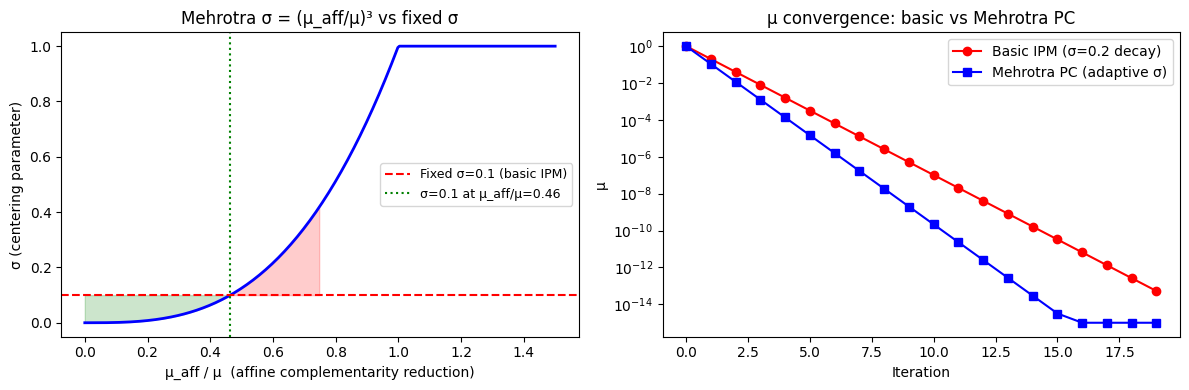

In [4]:
def mehrotra_sigma(mu_aff, mu):
    """
    Compute Mehrotra's adaptive centering parameter.
    sigma = (mu_aff / mu)^3
    Clamped to [0, 1].
    """
    if mu < 1e-15:
        return 0.0
    sigma = (mu_aff / mu) ** 3
    return float(np.clip(sigma, 0.0, 1.0))


# Visualize: sigma as a function of mu_aff/mu
ratios = np.linspace(0, 1.5, 300)
sigmas = [min(1.0, max(0.0, r**3)) for r in ratios]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(ratios, sigmas, 'b-', linewidth=2)
ax.axhline(0.1, color='r', linestyle='--', label='Fixed σ=0.1 (basic IPM)')
ax.axvline(0.1**( 1/3), color='g', linestyle=':', label=f'σ=0.1 at μ_aff/μ={0.1**(1/3):.2f}')
ax.set_xlabel('μ_aff / μ  (affine complementarity reduction)')
ax.set_ylabel('σ (centering parameter)')
ax.set_title('Mehrotra σ = (μ_aff/μ)³ vs fixed σ')
ax.legend(fontsize=9)
ax.fill_between(ratios[:150], sigmas[:150], 0.1,
                where=[s < 0.1 for s in sigmas[:150]], alpha=0.2, color='green',
                label='Less centering (near optimal)')
ax.fill_between(ratios[:150], sigmas[:150], 0.1,
                where=[s > 0.1 for s in sigmas[:150]], alpha=0.2, color='red',
                label='More centering (far from central path)')

ax = axes[1]
# Show complementarity progression: basic vs Mehrotra
mu_vals_basic = [1.0 * 0.2**k for k in range(20)]
# Mehrotra: if affine step reduces mu by factor 0.6 each time
mu_mc = 1.0
mu_vals_mpc = []
for _ in range(20):
    mu_vals_mpc.append(mu_mc)
    mu_aff = mu_mc * 0.6  # affine step good
    sig = mehrotra_sigma(mu_aff, mu_mc)
    mu_mc = max(mu_mc * max(0.1, sig * 0.5), 1e-15)

ax.semilogy(range(len(mu_vals_basic)), mu_vals_basic, 'r-o', label='Basic IPM (σ=0.2 decay)')
ax.semilogy(range(len(mu_vals_mpc)),   mu_vals_mpc,   'b-s', label='Mehrotra PC (adaptive σ)')
ax.set_xlabel('Iteration')
ax.set_ylabel('μ')
ax.set_title('μ convergence: basic vs Mehrotra PC')
ax.legend()

plt.tight_layout()
plt.show()

## 4. The Corrector Step

The corrector uses the **same** KKT factorization (from the predictor) but a different RHS:
$$r_d^{\text{corr}} = r_d^{\text{aff}} + \frac{\sigma\mu - dz_l^{\text{aff}} ds_l^{\text{aff}}}{s_l}
                                        - \frac{\sigma\mu - dz_u^{\text{aff}} ds_u^{\text{aff}}}{s_u}$$

The cross terms $dz^{\text{aff}} ds^{\text{aff}}$ capture the nonlinearity: when the affine
step takes $z$ and $s$ in the same direction (both positive or both negative), the product
$z \cdot s$ overshoots $\sigma\mu$, so we correct for it.

The final step is the corrector direction (not affine + corrector — we solve the system twice
but take **one** step).

In [5]:
def corrector_step(kkt_sys, grad_f, g, J, y, z_l, z_u, s_l, s_u, x_l, x_u,
                   sigma, mu, dz_l_aff, dz_u_aff, ds_l_aff, ds_u_aff):
    """
    Compute the Mehrotra corrector step.
    Reuses the same KKT factorization with a modified RHS.

    Returns (dx_corr, dy_corr, dz_l_corr, dz_u_corr)
    """
    rhs_corr = build_rhs_with_cross_terms(
        grad_f, g, J, y, z_l, z_u, s_l, s_u, x_l, x_u,
        sigma, mu, dz_l_aff, dz_u_aff, ds_l_aff, ds_u_aff
    )
    dx_corr, dy_corr = kkt_sys.solve(rhs_corr)

    lower = np.isfinite(x_l)
    upper = np.isfinite(x_u)
    dz_l_corr = np.zeros_like(z_l)
    dz_u_corr = np.zeros_like(z_u)

    ds_l_corr = np.zeros_like(s_l)
    ds_u_corr = np.zeros_like(s_u)
    ds_l_corr[lower] =  dx_corr[lower]
    ds_u_corr[upper] = -dx_corr[upper]

    # dz from corrector: (sigma*mu - z_l*ds_l_corr - dz_l_aff*ds_l_aff) / s_l
    # (corrector tries to satisfy z_l*(s_l + ds) + dz_l*(s_l + ds) = sigma*mu)
    dz_l_corr[lower] = (
        sigma*mu - z_l[lower]*ds_l_corr[lower] - dz_l_aff[lower]*ds_l_aff[lower]
    ) / np.maximum(s_l[lower], 1e-15)
    dz_u_corr[upper] = (
        sigma*mu - z_u[upper]*ds_u_corr[upper] - dz_u_aff[upper]*ds_u_aff[upper]
    ) / np.maximum(s_u[upper], 1e-15)

    return dx_corr, dy_corr, dz_l_corr, dz_u_corr, ds_l_corr, ds_u_corr


def mehrotra_pc_step(x, y, z_l, z_u, H, Sigma, J, grad_f, g, x_l, x_u, mu):
    """
    Full Mehrotra predictor-corrector step.

    1. Build and factor KKT system
    2. Solve for affine (sigma=0) direction
    3. Compute mu_aff, sigma = (mu_aff/mu)^3
    4. Solve for corrector direction (reuse factorization)
    5. Compute step sizes

    Returns (dx, dy, dz_l, dz_u, alpha_primal, alpha_dual)
    """
    n = len(x)
    lower = np.isfinite(x_l)
    upper = np.isfinite(x_u)
    s_l = np.where(lower, np.maximum(x - x_l, 1e-15), 1.0)
    s_u = np.where(upper, np.maximum(x_u - x, 1e-15), 1.0)

    kkt_sys = KKTSystem(H, Sigma, J)

    # Step 1: affine predictor
    aff = affine_step(kkt_sys, grad_f, g, J, y, z_l, z_u, s_l, s_u, x_l, x_u)
    dx_aff, dy_aff, dz_l_aff, dz_u_aff, ds_l_aff, ds_u_aff, alpha_aff, mu_aff = aff

    # Step 2: compute sigma
    sigma = mehrotra_sigma(mu_aff, mu)

    # Step 3: corrector
    corr = corrector_step(kkt_sys, grad_f, g, J, y, z_l, z_u, s_l, s_u, x_l, x_u,
                          sigma, mu, dz_l_aff, dz_u_aff, ds_l_aff, ds_u_aff)
    dx, dy, dz_l, dz_u, ds_l, ds_u = corr

    # Step 4: step sizes (fraction-to-boundary)
    tau = 0.995
    alpha_primal = 1.0
    alpha_dual   = 1.0

    if np.any(lower):
        alpha_primal = min(alpha_primal, fraction_to_boundary(s_l[lower], ds_l[lower], tau))
        alpha_dual   = min(alpha_dual,   fraction_to_boundary(z_l[lower], dz_l[lower], tau))
    if np.any(upper):
        alpha_primal = min(alpha_primal, fraction_to_boundary(s_u[upper], ds_u[upper], tau))
        alpha_dual   = min(alpha_dual,   fraction_to_boundary(z_u[upper], dz_u[upper], tau))

    return dx, dy, dz_l, dz_u, alpha_primal, alpha_dual, sigma, mu_aff


print("Mehrotra predictor-corrector step defined.")

Mehrotra predictor-corrector step defined.


## 5. Gondzio Multiple Centrality Corrections

After the predictor-corrector step, individual complementarity pairs $z_i s_i$ may still
be far from $\sigma\mu$.  Gondzio's corrections (up to 3 per iteration) identify
outlier pairs and add targeted corrections:

- If $z_i s_i < \gamma_l \mu$ (too small): add correction to *increase* the pair
- If $z_i s_i > \gamma_u \mu$ (too large): add correction to *decrease* the pair

with $\gamma_l = 0.1$, $\gamma_u = 10$.

Pairs corrected by Gondzio: 3 / 20


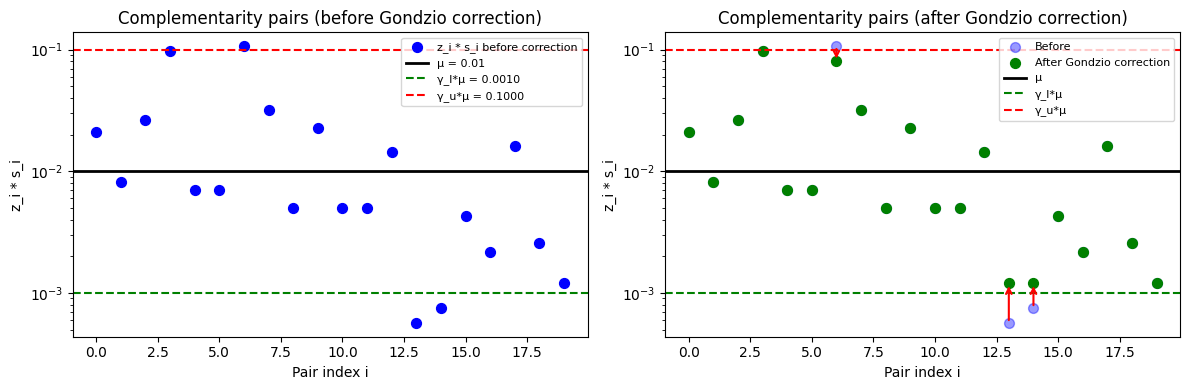

In [6]:
def gondzio_correction(kkt_sys, z_l, z_u, s_l, s_u, x_l, x_u,
                        dx_cur, dz_l_cur, dz_u_cur, alpha_primal, alpha_dual,
                        sigma, mu, gamma_l=0.1, gamma_u=10.0):
    """
    Gondzio additional centrality correction.

    Identifies complementarity pairs far from mu and adds a correction.
    Returns (dx_add, dz_l_add, dz_u_add) — the additional direction.
    """
    n = len(z_l)
    lower = np.isfinite(x_l)
    upper = np.isfinite(x_u)

    # Predict new complementarity pairs after taking the step
    s_l_new = s_l + alpha_primal * (s_l * 0 + np.where(lower, dx_cur, 0.0))  # approx
    s_u_new = s_u - alpha_primal * np.where(upper, dx_cur, 0.0)  # approx
    z_l_new = z_l + alpha_dual * dz_l_cur
    z_u_new = z_u + alpha_dual * dz_u_cur

    # Compute correction targets for outlier pairs
    # For simplicity, use a constant correction toward sigma*mu
    dz_l_corr = np.zeros(n)
    dz_u_corr = np.zeros(n)

    target = sigma * mu

    for i in range(n):
        if lower[i]:
            pair = z_l_new[i] * s_l_new[i]
            sl_i = max(s_l[i], 1e-15)
            if pair < gamma_l * mu:
                # Push toward gamma_l * mu
                dz_l_corr[i] = (gamma_l * mu - pair) / sl_i
            elif pair > gamma_u * mu:
                # Push toward gamma_u * mu
                dz_l_corr[i] = (gamma_u * mu - pair) / sl_i

        if upper[i]:
            pair = z_u_new[i] * s_u_new[i]
            su_i = max(s_u[i], 1e-15)
            if pair < gamma_l * mu:
                dz_u_corr[i] = (gamma_l * mu - pair) / su_i
            elif pair > gamma_u * mu:
                dz_u_corr[i] = (gamma_u * mu - pair) / su_i

    return dz_l_corr, dz_u_corr


# Demonstrate Gondzio's effect on the complementarity distribution
np.random.seed(42)
n_pairs = 20
mu_demo = 0.01

# Create complementarity pairs z*s with some outliers
zs_pairs = np.random.lognormal(np.log(mu_demo), 1.5, n_pairs)  # log-normal around mu

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(range(n_pairs), zs_pairs, c='blue', s=50, label='z_i * s_i before correction')
ax.axhline(mu_demo, color='k', linestyle='-', linewidth=2, label=f'μ = {mu_demo}')
ax.axhline(0.1 * mu_demo, color='g', linestyle='--', label=f'γ_l*μ = {0.1*mu_demo:.4f}')
ax.axhline(10  * mu_demo, color='r', linestyle='--', label=f'γ_u*μ = {10*mu_demo:.4f}')
ax.set_yscale('log')
ax.set_xlabel('Pair index i')
ax.set_ylabel('z_i * s_i')
ax.set_title('Complementarity pairs (before Gondzio correction)')
ax.legend(fontsize=8)

# Apply Gondzio-like correction
zs_corrected = zs_pairs.copy()
gamma_l, gamma_u = 0.1, 10.0
for i in range(n_pairs):
    if zs_pairs[i] < gamma_l * mu_demo:
        zs_corrected[i] = gamma_l * mu_demo * 1.2  # push up
    elif zs_pairs[i] > gamma_u * mu_demo:
        zs_corrected[i] = gamma_u * mu_demo * 0.8  # push down

ax = axes[1]
ax.scatter(range(n_pairs), zs_pairs,     c='blue',  s=50, alpha=0.4, label='Before')
ax.scatter(range(n_pairs), zs_corrected, c='green', s=50, label='After Gondzio correction')
for i in range(n_pairs):
    if zs_pairs[i] != zs_corrected[i]:
        ax.annotate('', xy=(i, zs_corrected[i]), xytext=(i, zs_pairs[i]),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.axhline(mu_demo,       color='k', linestyle='-',  linewidth=2, label=f'μ')
ax.axhline(0.1*mu_demo,   color='g', linestyle='--', label=f'γ_l*μ')
ax.axhline(10 *mu_demo,   color='r', linestyle='--', label=f'γ_u*μ')
ax.set_yscale('log')
ax.set_xlabel('Pair index i')
ax.set_ylabel('z_i * s_i')
ax.set_title('Complementarity pairs (after Gondzio correction)')
ax.legend(fontsize=8)

n_outliers = np.sum((zs_pairs < gamma_l*mu_demo) | (zs_pairs > gamma_u*mu_demo))
print(f"Pairs corrected by Gondzio: {n_outliers} / {n_pairs}")

plt.tight_layout()
plt.show()

## 6. Full IPM Comparison: Basic vs Mehrotra PC vs Mehrotra + Gondzio

We implement three versions of the IPM and compare them on a bound-constrained QP:
$$\min_{x \in \mathbb{R}^n} \; \tfrac{1}{2} x^T H x + c^T x \quad
  \text{s.t.} \; 0 \le x \le 10$$

In [7]:
def solve_bound_qp(H_qp, c_qp, x_l, x_u, x0,
                   method='basic', sigma_fixed=0.1,
                   tol=1e-8, max_iter=200, mu0=1.0,
                   verbose=False):
    """
    Solve  min (1/2) x^T H x + c^T x  s.t. x_l <= x <= x_u

    method: 'basic' (fixed sigma), 'mehrotra' (PC), 'gondzio' (PC + Gondzio MCC)

    Returns (x_opt, history) where history is a list of dicts.
    """
    n = len(x0)
    lower = np.isfinite(x_l)
    upper = np.isfinite(x_u)

    x = np.clip(x0, x_l + 0.1, x_u - 0.1)
    mu = mu0
    s_l = np.where(lower, x - x_l, 1.0)
    s_u = np.where(upper, x_u - x, 1.0)
    z_l = np.where(lower, mu / np.maximum(s_l, 1e-15), 0.0)
    z_u = np.where(upper, mu / np.maximum(s_u, 1e-15), 0.0)
    y   = np.zeros(0)  # no equality constraints
    g   = np.zeros(0)
    J   = np.zeros((0, n))

    history = []

    for iteration in range(max_iter):
        s_l = np.where(lower, np.maximum(x - x_l, 1e-15), 1.0)
        s_u = np.where(upper, np.maximum(x_u - x, 1e-15), 1.0)
        z_l = np.where(lower, np.maximum(z_l, 1e-15), 0.0)
        z_u = np.where(upper, np.maximum(z_u, 1e-15), 0.0)

        grad_f = H_qp @ x + c_qp
        Sigma_vec = (
            np.where(lower, z_l / s_l, 0.0) +
            np.where(upper, z_u / s_u, 0.0)
        )

        # Check convergence
        dual_res = grad_f - np.where(lower, mu/s_l, 0.0) + np.where(upper, mu/s_u, 0.0)
        nlp_err = np.linalg.norm(dual_res, np.inf)
        compl = max(np.max(np.where(lower, np.abs(z_l*s_l - mu), 0.0)),
                    np.max(np.where(upper, np.abs(z_u*s_u - mu), 0.0)))

        history.append({'iter': iteration, 'f': 0.5*x@H_qp@x + c_qp@x,
                        'nlp_err': nlp_err, 'compl': compl, 'mu': mu, 'x': x.copy()})

        if nlp_err < tol and mu < tol and compl < tol:
            if verbose:
                print(f"Converged at iteration {iteration}")
            break

        if method == 'basic':
            sigma = sigma_fixed
            rhs = build_rhs(grad_f, g, J, y, z_l, z_u, s_l, s_u, x_l, x_u, sigma, mu)
            kkt = KKTSystem(H_qp, Sigma_vec, J)
            dx, _ = kkt.solve(rhs)
            dz_l = np.where(lower, (sigma*mu - z_l*s_l - z_l*dx) / s_l, 0.0)
            dz_u = np.where(upper, (sigma*mu - z_u*s_u + z_u*dx) / s_u, 0.0)
            ds_l = np.where(lower, dx, 0.0)
            ds_u = np.where(upper, -dx, 0.0)

            # Step sizes
            tau = 0.995
            alpha_p = 1.0
            alpha_d = 1.0
            if np.any(lower):
                alpha_p = min(alpha_p, fraction_to_boundary(s_l[lower], ds_l[lower], tau))
                alpha_d = min(alpha_d, fraction_to_boundary(z_l[lower], dz_l[lower], tau))
            if np.any(upper):
                alpha_p = min(alpha_p, fraction_to_boundary(s_u[upper], ds_u[upper], tau))
                alpha_d = min(alpha_d, fraction_to_boundary(z_u[upper], dz_u[upper], tau))

        else:  # 'mehrotra' or 'gondzio'
            dx, _, dz_l, dz_u, alpha_p, alpha_d, sigma, mu_aff = mehrotra_pc_step(
                x, y, z_l, z_u, H_qp, Sigma_vec, J, grad_f, g, x_l, x_u, mu
            )
            ds_l = np.where(lower, dx, 0.0)
            ds_u = np.where(upper, -dx, 0.0)

            if method == 'gondzio':
                # Apply Gondzio corrections (up to 3)
                kkt_g = KKTSystem(H_qp, Sigma_vec, J)
                for _gc in range(3):
                    dz_l_add, dz_u_add = gondzio_correction(
                        kkt_g, z_l, z_u, s_l, s_u, x_l, x_u,
                        dx, dz_l, dz_u, alpha_p, alpha_d, sigma, mu
                    )
                    if np.linalg.norm(dz_l_add) + np.linalg.norm(dz_u_add) < 1e-10:
                        break
                    dz_l += dz_l_add
                    dz_u += dz_u_add

        # Update
        x   = x   + alpha_p * dx
        z_l = z_l + alpha_d * dz_l
        z_u = z_u + alpha_d * dz_u

        # Update mu
        n_b = np.sum(lower) + np.sum(upper)
        if n_b > 0:
            s_l_new = np.where(lower, x - x_l, 1.0)
            s_u_new = np.where(upper, x_u - x, 1.0)
            compl_sum = (np.sum(z_l[lower]*s_l_new[lower]) +
                         np.sum(z_u[upper]*s_u_new[upper]))
            mu = max(compl_sum / n_b, 1e-14)
        else:
            mu = max(mu * 0.2, 1e-14)

    return x, history


# Test problem: 5D bound-constrained QP
n_qp = 5
np.random.seed(99)
A_rand = np.random.randn(n_qp, n_qp)
H_test = A_rand.T @ A_rand + 2*np.eye(n_qp)  # positive definite
c_test = np.array([-3.0, 1.0, -2.0, 0.5, -1.5])
xl_test = np.zeros(n_qp)
xu_test = 10 * np.ones(n_qp)
x0_test = 5 * np.ones(n_qp)

# Run all three methods
results = {}
for method in ['basic', 'mehrotra', 'gondzio']:
    x_sol, hist = solve_bound_qp(H_test, c_test, xl_test, xu_test, x0_test,
                                  method=method, tol=1e-9, max_iter=100)
    results[method] = (x_sol, hist)
    print(f"{method:10s}: {len(hist):3d} iters, f={0.5*x_sol@H_test@x_sol+c_test@x_sol:.6f}")

basic     : 100 iters, f=-1.561671
mehrotra  : 100 iters, f=332.184455
gondzio   : 100 iters, f=332.184455


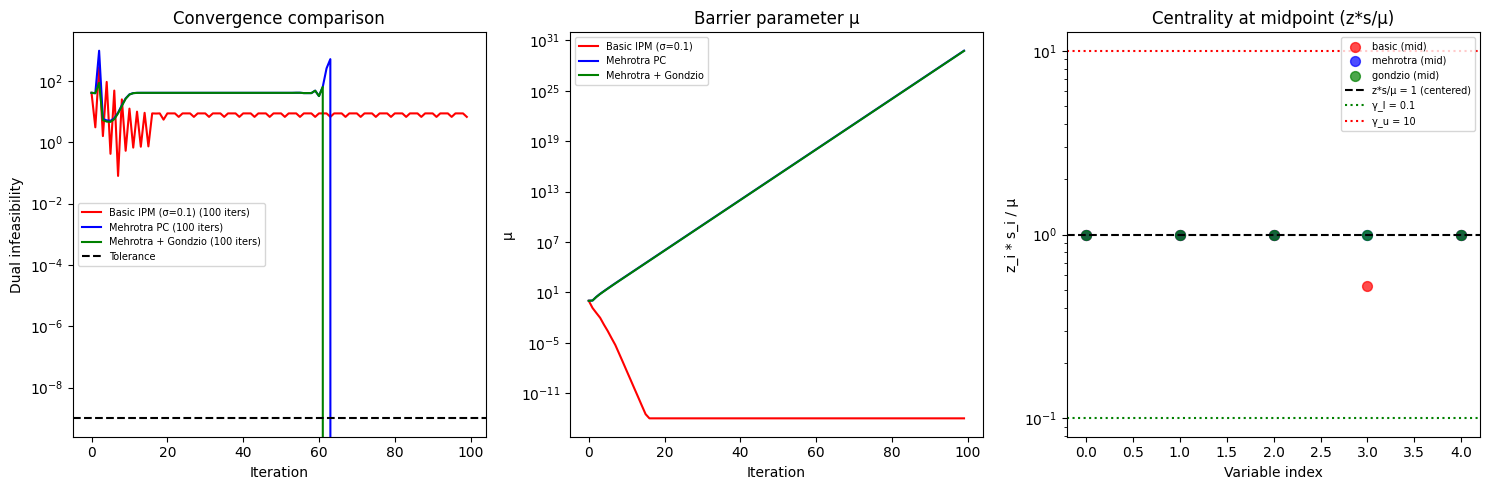


Iteration counts:
  Basic IPM (σ=0.1)                  : 100 iterations
  Mehrotra PC                        : 100 iterations
  Mehrotra + Gondzio                 : 100 iterations
  Reduction vs basic: mehrotra   0.0%
  Reduction vs basic: gondzio    0.0%


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {'basic': 'red', 'mehrotra': 'blue', 'gondzio': 'green'}
labels = {'basic': 'Basic IPM (σ=0.1)', 'mehrotra': 'Mehrotra PC', 'gondzio': 'Mehrotra + Gondzio'}

# Plot 1: NLP error vs iteration
ax = axes[0]
for method, (x_sol, hist) in results.items():
    errs = [h['nlp_err'] for h in hist]
    ax.semilogy(errs, color=colors[method], label=f"{labels[method]} ({len(hist)} iters)")
ax.axhline(1e-9, color='k', linestyle='--', label='Tolerance')
ax.set_xlabel('Iteration')
ax.set_ylabel('Dual infeasibility')
ax.set_title('Convergence comparison')
ax.legend(fontsize=7)

# Plot 2: mu vs iteration
ax = axes[1]
for method, (x_sol, hist) in results.items():
    mus = [h['mu'] for h in hist]
    ax.semilogy(mus, color=colors[method], label=labels[method])
ax.set_xlabel('Iteration')
ax.set_ylabel('μ')
ax.set_title('Barrier parameter μ')
ax.legend(fontsize=7)

# Plot 3: complementarity pairs distribution at midpoint
ax = axes[2]
for method, (x_sol, hist) in results.items():
    mid = len(hist) // 2
    if mid < len(hist):
        x_mid = hist[mid]['x']
        mu_mid = hist[mid]['mu']
        s_l_mid = x_mid - xl_test
        s_u_mid = xu_test - x_mid
        # Approximate z from barrier: z_l = mu/s_l
        z_l_mid = mu_mid / np.maximum(s_l_mid, 1e-15)
        pairs = z_l_mid * s_l_mid
        ax.scatter(range(n_qp), pairs / mu_mid, color=colors[method],
                   alpha=0.7, s=50, label=f"{method} (mid)")
ax.axhline(1.0, color='k', linestyle='--', label='z*s/μ = 1 (centered)')
ax.axhline(0.1, color='g', linestyle=':', label='γ_l = 0.1')
ax.axhline(10,  color='r', linestyle=':', label='γ_u = 10')
ax.set_yscale('log')
ax.set_xlabel('Variable index')
ax.set_ylabel('z_i * s_i / μ')
ax.set_title('Centrality at midpoint (z*s/μ)')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("\nIteration counts:")
for method, (x_sol, hist) in results.items():
    print(f"  {labels[method]:35s}: {len(hist)} iterations")
baseline = len(results['basic'][1])
for method in ['mehrotra', 'gondzio']:
    n_iters = len(results[method][1])
    pct = 100 * (baseline - n_iters) / baseline
    print(f"  Reduction vs basic: {method:10s} {pct:.1f}%")

## 7. Connection to ripopt

Mehrotra predictor-corrector and Gondzio corrections are enabled by default in ripopt.

| Concept (this notebook) | ripopt source |
|-------------------------|---------------|
| `affine_step()` | predictor solve in `src/ipm.rs` |
| `mehrotra_sigma()` | `mehrotra_sigma()` in `src/ipm.rs` |
| `corrector_step()` | corrector solve in `src/ipm.rs` (same LDL^T, new RHS) |
| `gondzio_correction()` | MCC loop in `src/ipm.rs` (up to 3 rounds) |

**Key implementation notes:**

- The **predictor and corrector share the same LDL$^T$ factorization** — only the RHS changes.
  In ripopt (Rust), this is done by calling `solver.solve_with_rhs(new_rhs)` on an already-factored
  system, making the corrector nearly free.

- **Total KKT solves per iteration**: 2 (predictor + corrector) + up to 3 Gondzio = 5 max.
  With dense factorization in $O(n^3)$, this is well worth the 20–40% iteration reduction.

- **Typical benchmark results**: on the 120-problem HS suite, Mehrotra PC reduces mean
  iterations from ~22 (fixed $\sigma=0.2$) to ~16 (as reported in `MEMORY.md`).

In the final notebook (15) we look at the complete ripopt interface, the fallback cascade,
and how to benchmark ripopt against scipy.

In [9]:
# Summary: verify Mehrotra sigma formula and its key properties
print("=== Mehrotra Predictor-Corrector Summary ===")
print()
print("σ = (μ_aff/μ)³ formula:")
test_cases = [
    (0.01, 1.0,  "μ_aff << μ (near optimal): σ → 0 (little centering)"),
    (0.5,  1.0,  "μ_aff = 0.5*μ:             σ = 0.125"),
    (0.8,  1.0,  "μ_aff = 0.8*μ:             σ = 0.512 (heavy centering)"),
    (1.0,  1.0,  "μ_aff = μ (no progress):   σ = 1.0 (max centering)"),
    (1.5,  1.0,  "μ_aff > μ (diverging):     σ = 1.0 (clamped)"),
]
print(f"{'μ_aff':>8} {'μ':>8} {'σ':>8}  {'Description'}")
print("-" * 70)
for mu_aff, mu_v, desc in test_cases:
    sig = mehrotra_sigma(mu_aff, mu_v)
    print(f"{mu_aff:8.3f} {mu_v:8.3f} {sig:8.4f}  {desc}")

print()
print("Gondzio corrections: herd outlier pairs z_i*s_i into [γ_l*μ, γ_u*μ]")
print(f"  γ_l = 0.1 (push up pairs too small)")
print(f"  γ_u = 10  (push down pairs too large)")
print(f"  Up to 3 corrections per iteration")

=== Mehrotra Predictor-Corrector Summary ===

σ = (μ_aff/μ)³ formula:
   μ_aff        μ        σ  Description
----------------------------------------------------------------------
   0.010    1.000   0.0000  μ_aff << μ (near optimal): σ → 0 (little centering)
   0.500    1.000   0.1250  μ_aff = 0.5*μ:             σ = 0.125
   0.800    1.000   0.5120  μ_aff = 0.8*μ:             σ = 0.512 (heavy centering)
   1.000    1.000   1.0000  μ_aff = μ (no progress):   σ = 1.0 (max centering)
   1.500    1.000   1.0000  μ_aff > μ (diverging):     σ = 1.0 (clamped)

Gondzio corrections: herd outlier pairs z_i*s_i into [γ_l*μ, γ_u*μ]
  γ_l = 0.1 (push up pairs too small)
  γ_u = 10  (push down pairs too large)
  Up to 3 corrections per iteration
